# Grundlagen der Künstlichen Intelligenz.
# Exercise 5. Clustering Analysis with K-Means and DBSCAN

**Autor:** Arturo Olivares Martos
***

- **Asignatura:** Grundlagen der Künstlichen Intelligenz.
- **Curso Académico:** 2025-26.
- **Grado:** Doble Grado en Ingeniería Informática y Matemáticas.
- **Grupo:** Erasmus.
- **Profesor:** Gérald Kämmerer
- **Descripción:** Práctica 5 de la asignatura GKI
<!--- **Fecha:** 17 de abril de 2023. -->
<!-- - **Duración:** -->

Use Scikit-Learn’s built-in datasets (`load_iris` and `make_moons`) to investigate how K-Means and DBSCAN work, experiment with hyperparameters, and visualize the results.

Load the dataset and prepare the features. Since clustering algorithms are sensitive to feature scaling, perform a standardization.

In [5]:
# Load and scale the data
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()
print(iris.DESCR)  # Display the dataset description

X = iris.data  # Using all numerical features
print("Original Data Shape:", X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

Implement and test K-Means clustering using Scikit-Learn’s built-in module.

In [2]:
# K-Means Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

Now implement and test DBSCAN. Use the documentation to experiment with the parameters.

In [14]:
# DBSCAN Clustering
from sklearn.cluster import DBSCAN

# Play around with eps (e.g., 0.2, 0.5, 1.2) and min_samples (e.g., 3, 5, 10)
dbscan = DBSCAN(eps=1.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Determine the number of detected clusters and noise points (-1)
import numpy as np
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"Estimated number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

Estimated number of clusters: 2
Number of noise points: 1


Visualize and compare the results of both algorithms in a scatter plot (use the first two principal components or two significant features).

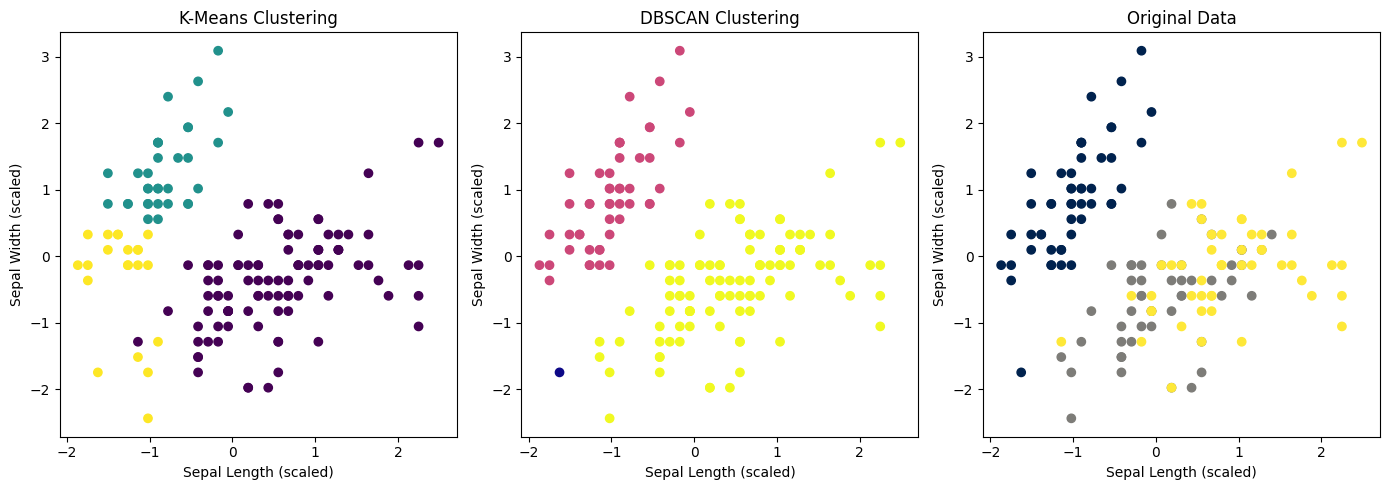

In [15]:
# Visualizing the cluster comparison
import matplotlib.pyplot as plt
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

# K-Means Plot
ax1.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis')
ax1.set_title("K-Means Clustering")
ax1.set_xlabel("Sepal Length (scaled)")
ax1.set_ylabel("Sepal Width (scaled)")

# DBSCAN Plot
ax2.scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels, cmap='plasma')
ax2.set_title("DBSCAN Clustering")
ax2.set_xlabel("Sepal Length (scaled)")
ax2.set_ylabel("Sepal Width (scaled)")

# Original Data Plot
ax3.scatter(X_scaled[:, 0], X_scaled[:, 1], c=iris.target, cmap='cividis')
ax3.set_title("Original Data")
ax3.set_xlabel("Sepal Length (scaled)")
ax3.set_ylabel("Sepal Width (scaled)")

plt.tight_layout()
plt.show()

Evaluate the clustering quality using the Silhouette Score for both methods
(Note: pay attention to noise points in DBSCAN!).

In [13]:
# Validation

from sklearn.metrics import silhouette_score

# Silhouette Score for K-Means
print("Silhouette Score K-Means:", silhouette_score(X_scaled, kmeans_labels))

# Silhouette Score for DBSCAN (excluding noise)
# For DBSCAN, only evaluate points that are not noise:
mask = dbscan_labels != -1
if len(set(dbscan_labels[mask])) > 1:
    print("Silhouette Score DBSCAN (excluding noise):", silhouette_score(X_scaled[mask], dbscan_labels[mask]))

# Silhouette Score for the original data (using true labels)
print("Silhouette Score Original Data:", silhouette_score(X_scaled, iris.target))

# // TODO: Qué es este parámetro?
# // TODO: Tiene sentido hacerlo para el original?



Silhouette Score K-Means: 0.4798814508199817
Silhouette Score DBSCAN (excluding noise): 0.6558885287002016
Silhouette Score Original Data: 0.3811261580543803


Generate a synthetic, half-moon-shaped dataset using `sklearn.datasets.make_moons`. Apply both algorithms to it. What do you observe? Discuss the behavior of K-Means vs. DBSCAN when dealing with non-linear cluster structures.

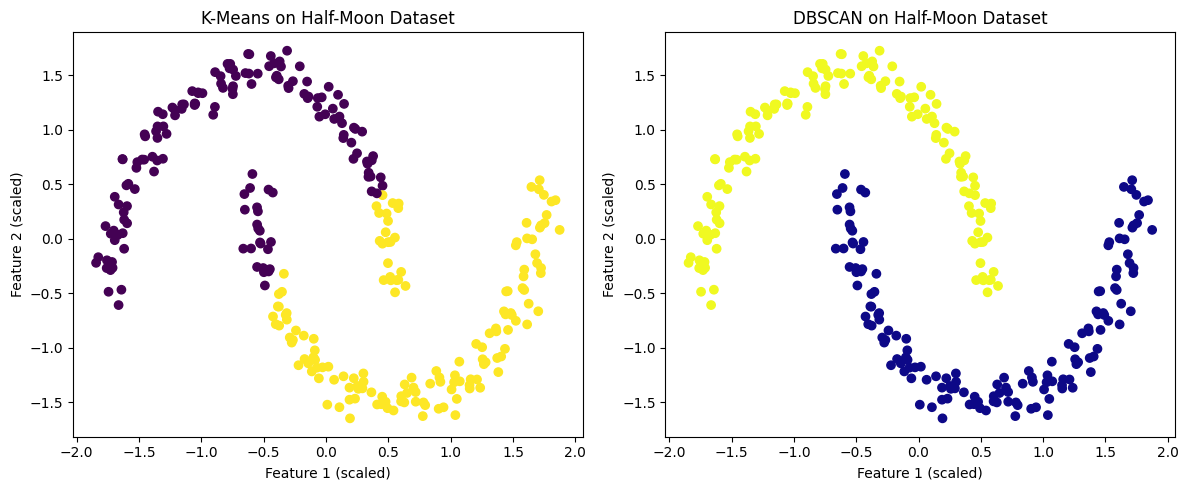

In [17]:
from sklearn.datasets import make_moons

# Generate synthetic half-moon-shaped dataset
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)

# Scale the data
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

# K-Means on half-moon dataset
kmeans_moons = KMeans(n_clusters=2, random_state=42)
kmeans_moons_labels = kmeans_moons.fit_predict(X_moons_scaled)

# DBSCAN on half-moon dataset
dbscan_moons = DBSCAN(eps=0.3, min_samples=5)
dbscan_moons_labels = dbscan_moons.fit_predict(X_moons_scaled)

# Visualize the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=kmeans_moons_labels, cmap='viridis')
ax1.set_title("K-Means on Half-Moon Dataset")
ax1.set_xlabel("Feature 1 (scaled)")
ax1.set_ylabel("Feature 2 (scaled)")

ax2.scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=dbscan_moons_labels, cmap='plasma')
ax2.set_title("DBSCAN on Half-Moon Dataset")
ax2.set_xlabel("Feature 1 (scaled)")
ax2.set_ylabel("Feature 2 (scaled)")

plt.tight_layout()
plt.show()

As the reader may notice, DBSCAN is a density-based clustering algorithm that can identify clusters of arbitrary shape and is robust to noise, while K-Means is a centroid-based algorithm that assumes clusters are spherical and may struggle with non-linear structures. When applied to the half-moon-shaped dataset, K-Means may fail to capture the true cluster structure, while DBSCAN should be able to identify the two distinct moon-shaped clusters effectively.